# DemoModes

Run a simulation episode split across multiple control **phases**, each with its own action and duration. Phases are defined as fractions of the total steps and run sequentially — the final state of each phase is the initial state of the next.

In [1]:
import sys
print(sys.executable)

import jax
print("jax:", jax.__version__)

/bigdata/rhome/jbuh2025/Transformable-Leg-Wheel-Robot/.venv/bin/python
jax: 0.8.2


In [2]:
%env MUJOCO_GL=egl

import functools
import os
import time
import mujoco
import numpy as np

import jax
import mediapy as media
from tqdm import tqdm
import twmr  # noqa: F401
import warp as wp
from jax import numpy as jp
from mujoco_playground import registry

wp.config.quiet = True

media.set_ffmpeg("/bigdata/rhome/jbuh2025/Transformable-Leg-Wheel-Robot/.pixi/envs/default/bin/ffmpeg")

xla_flags = os.environ.get("XLA_FLAGS", "")
xla_flags += " --xla_gpu_triton_gemm_any=True"
os.environ["XLA_FLAGS"] = xla_flags

env = registry.load("TWMRLegFlat")
initial_state = env.reset(jax.random.PRNGKey(0))

env: MUJOCO_GL=egl


In [3]:
# ── Phase configuration ───────────────────────────────────────────────────────
N_STEPS = 1000  # total simulation steps across all phases

phases = [
    {
        # "action":   jp.array([1.0, 1.0,  1.0, 1.0, 3.0, 3.0, 3.0, 3.0]),
        # "action":   jp.array([0.0, 0.0,  0.0, 0.0, 0.0, 0.0, 0.0, 0.0]),
        "action":   jp.array([0.0, 0.0,  0.0, 0.0, -3.0, -3.0, -3.0, -3.0]),
        
        
        "fraction": 0.30,  # 30% of N_STEPS
    },
    {
        "action":   jp.array([1.0, 1.0, 1.0,  1.0, 3.0, 3.0, 0.0, 0.0]),
        # "action":   jp.array([0.0, 0.0,  0.0, 0.0, -3.0, -3.0, -3.0, -3.0]),
        # "action":   jp.array([0.0, 0.0,  0.0, 0.0, 3.0, 3.0, 3.0, 3.0]),
        
        
        "fraction": 0.70,  # 70% of N_STEPS
    },
]
# ─────────────────────────────────────────────────────────────────────────────

assert abs(sum(p["fraction"] for p in phases) - 1.0) < 1e-6, \
    "Phase fractions must sum to 1.0"

# Compute integer step counts; last phase absorbs any rounding remainder
step_counts = [round(N_STEPS * p["fraction"]) for p in phases]
step_counts[-1] = N_STEPS - sum(step_counts[:-1])


# n_steps must be a compile-time constant for jax.lax.scan,
# so mark it static — each unique value triggers one JIT compilation.
@functools.partial(jax.jit, static_argnums=(2,))
def run_phase(initial_state, action, n_steps):
    def step_fn(state, _):
        state = env.step(state=state, action=action)
        return state, state
    return jax.lax.scan(step_fn, initial_state, None, length=n_steps)


state = initial_state
rollouts = []  # one stacked-State per phase

for i, (phase, n) in enumerate(zip(phases, step_counts)):
    print(f"Phase {i + 1}: {n} steps (action={phase['action'].tolist()}) ...")
    t0 = time.perf_counter()
    state, rollout = run_phase(state, phase["action"], n)
    rollout.data.qpos.block_until_ready()
    t1 = time.perf_counter()
    print(f"  done in {t1 - t0:.2f}s  ({n / (t1 - t0):.0f} steps/s)")
    rollouts.append(rollout)

print(f"\nFinal position: {state.data.qpos}")

Phase 1: 300 steps (action=[0.0, 0.0, 0.0, 0.0, -3.0, -3.0, -3.0, -3.0]) ...
  done in 2.28s  (132 steps/s)
Phase 2: 700 steps (action=[1.0, 1.0, 1.0, 1.0, 3.0, 3.0, 0.0, 0.0]) ...
  done in 3.03s  (231 steps/s)

Final position: [ 5.8570868e-01  4.4018609e-08  3.4865029e-02  1.0000000e+00
 -1.2385197e-10  4.4934276e-07  7.8059976e-08  1.8537668e+01
  3.4360812e+00  3.4358485e+00  3.4358432e+00  1.8537668e+01
  3.4360812e+00  3.4358485e+00  3.4358435e+00  2.2532553e+01
 -1.0469271e+00 -1.0469230e+00 -1.0469316e+00  2.2532553e+01
 -1.0469271e+00 -1.0469230e+00 -1.0469316e+00]


In [4]:
# ── Adjustable camera parameter ──────────────────────────────────────────────
camera_distance = 1.5  # meters; increase to zoom out, decrease to zoom in
# ─────────────────────────────────────────────────────────────────────────────


def render_phases(env, rollouts, camera_distance=1.5, height=480, width=640):
    """Render a list of phase rollouts (each a stacked State) into one video."""
    mj_model = env.mj_model
    renderer = mujoco.Renderer(mj_model, height=height, width=width)

    cam = mujoco.MjvCamera()
    mujoco.mjv_defaultFreeCamera(mj_model, cam)
    cam.azimuth = 135.0    # 3/4 rear view
    cam.elevation = -20.0  # slight downward angle
    cam.distance = camera_distance

    chassis_id = mujoco.mj_name2id(mj_model, mujoco.mjtObj.mjOBJ_BODY, "chassis")
    if chassis_id < 0:
        chassis_id = mujoco.mj_name2id(mj_model, mujoco.mjtObj.mjOBJ_BODY, "root")
    if chassis_id < 0:
        chassis_id = 1

    # Pull all phases to CPU and concatenate along the time axis
    all_qpos       = np.concatenate([np.array(r.data.qpos)        for r in rollouts])
    all_qvel       = np.concatenate([np.array(r.data.qvel)        for r in rollouts])
    all_mocap_pos  = np.concatenate([np.array(r.data.mocap_pos)   for r in rollouts])
    all_mocap_quat = np.concatenate([np.array(r.data.mocap_quat)  for r in rollouts])
    all_xfrc       = np.concatenate([np.array(r.data.xfrc_applied) for r in rollouts])

    frames = []
    d = mujoco.MjData(mj_model)
    for i in tqdm(range(all_qpos.shape[0]), desc="Rendering frames"):
        d.qpos[:]        = all_qpos[i]
        d.qvel[:]        = all_qvel[i]
        d.mocap_pos[:]   = all_mocap_pos[i]
        d.mocap_quat[:]  = all_mocap_quat[i]
        d.xfrc_applied[:] = all_xfrc[i]
        mujoco.mj_forward(mj_model, d)

        cam.lookat[:] = d.xpos[chassis_id]
        renderer.update_scene(d, camera=cam)
        frames.append(renderer.render())

    renderer.close()
    return frames


frames = render_phases(env, rollouts, camera_distance=camera_distance)

media.show_video(frames, fps=1.0 / env.dt)
media.write_video("tlwr_demo_modes.mp4", frames, fps=1.0 / env.dt)

Rendering frames: 100%|██████████| 1000/1000 [00:01<00:00, 819.65it/s]


This browser does not support the video tag.


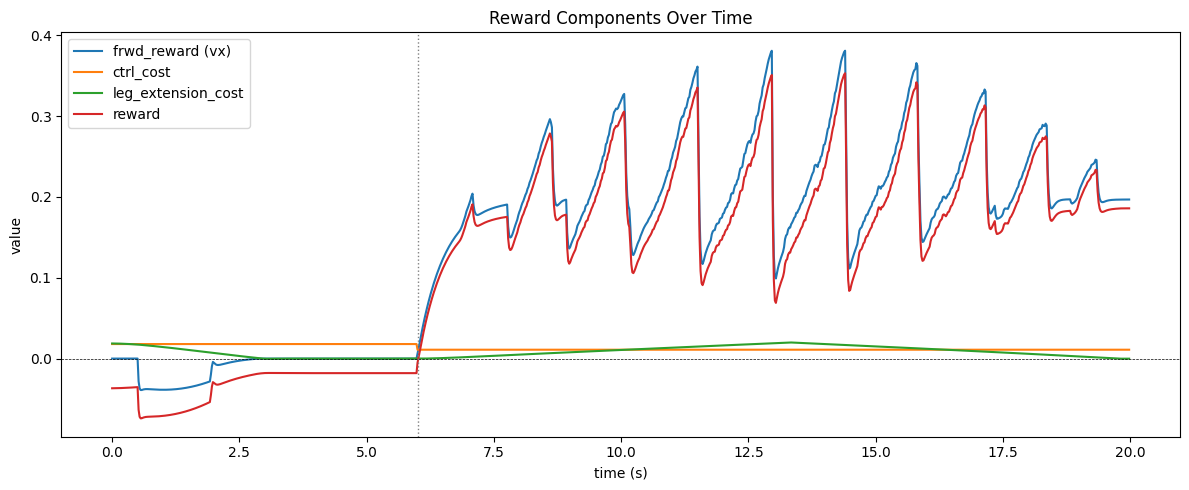

In [5]:
import matplotlib.pyplot as plt

# Concatenate data from all phases
all_qpos = np.concatenate([np.array(r.data.qpos) for r in rollouts])  # (T, nq)
all_qvel = np.concatenate([np.array(r.data.qvel) for r in rollouts])  # (T, nv)
all_ctrl = np.concatenate([np.array(r.data.ctrl) for r in rollouts])  # (T, nu)

### Per-step reward components

# Forward reward & control cost
vx          = all_qvel[:, 0]
frwd_reward = vx
ctrl_cost   = 0.0005 * np.sum(np.square(all_ctrl), axis=1)

# Leg extension cost: 0 when contracted, max when fully extended, linear
LEG_MIN = -1.047   # rad: contracted position
LEG_MAX =  3.427   # rad: fully extended position
LEG_FULL_EXTENDED = (LEG_MAX + LEG_MIN) / 2
HALF_RANGE = (LEG_MAX - LEG_MIN)/2 # rad: angle from fully contracted --> fully extended
leg_angles            = all_qpos[:, [8, 12, 16, 20]]                        # (T, 4)
leg_angles_normalized = 1 - (abs(leg_angles - LEG_FULL_EXTENDED)) / HALF_RANGE        # [0, 1] (1 --> extended, 0 --> contracted)
leg_extension_cost    = 0.01 * np.sum(leg_angles_normalized, axis=1)        # linear, (T,) CAN CHANGE TO QUADRATIC

reward = frwd_reward - ctrl_cost - leg_extension_cost

# Time axis
t = np.arange(len(vx)) * float(env.dt)

# Phase boundary lines
phase_boundaries = np.cumsum(step_counts[:-1])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t, frwd_reward,       label="frwd_reward (vx)")
ax.plot(t, ctrl_cost,         label="ctrl_cost")
ax.plot(t, leg_extension_cost, label="leg_extension_cost")
ax.plot(t, reward,            label="reward")
ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
for pb in phase_boundaries:
    ax.axvline(t[pb], color="gray", linewidth=1.0, linestyle=":", label="_phase boundary")
ax.set_xlabel("time (s)")
ax.set_ylabel("value")
ax.set_title("Reward Components Over Time")
ax.legend()
plt.tight_layout()
plt.show()

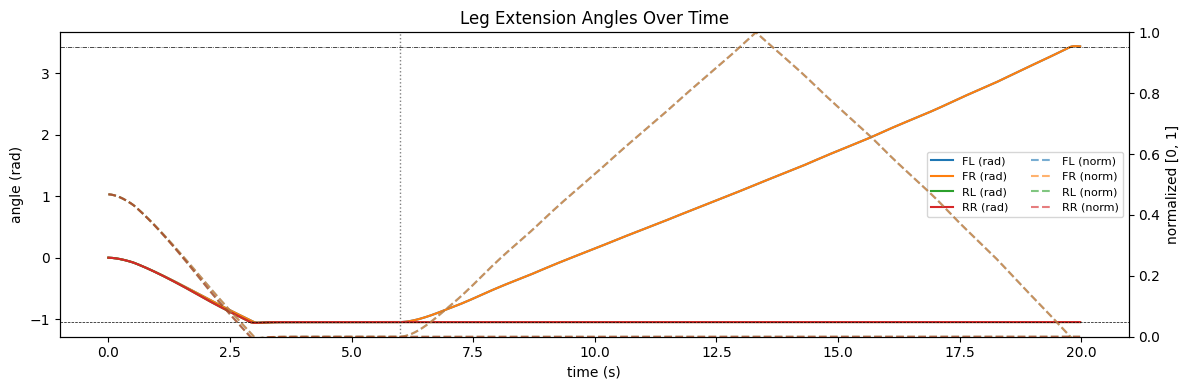

In [17]:
all_qpos_plot = np.concatenate([np.array(r.data.qpos) for r in rollouts])
leg_angles_plot = all_qpos_plot[:, [8, 12, 16, 20]]
leg_angles_norm_plot = 1 - (abs(leg_angles_plot - LEG_FULL_EXTENDED)) / HALF_RANGE
t_plot = np.arange(len(leg_angles_plot)) * float(env.dt)

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for i, name in enumerate(["FL", "FR", "RL", "RR"]):
    
    ax1.plot(t_plot, leg_angles_plot[:, i],      color=colors[i], linestyle="-",  label=f"{name} (rad)")
    ax2.plot(t_plot, leg_angles_norm_plot[:, i], color=colors[i], linestyle="--", alpha=0.6, label=f"{name} (norm)")

for pb in phase_boundaries:
    ax1.axvline(t_plot[pb], color="gray", linewidth=1.0, linestyle=":")
ax1.axhline(LEG_MIN, color="k", linewidth=0.5, linestyle="--")
ax1.axhline(LEG_MAX, color="k", linewidth=0.5, linestyle="-.")

ax1.set_xlabel("time (s)")
ax1.set_ylabel("angle (rad)")
ax2.set_ylabel("normalized [0, 1]")
ax2.set_ylim(0, 1)
ax1.set_title("Leg Extension Angles Over Time")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, ncol=2, fontsize=8)
plt.tight_layout()
plt.show()